<a href="https://colab.research.google.com/github/costpetrides/Air-pollution-COVID-19-impact/blob/main/pk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import BallTree

# ======================================================
# FIXED PARAMETERS
# ======================================================
p_fixed = 10
k_fixed = 8

# ======================================================
# 1. LOAD CSV DATA
# ======================================================
csv_file_path = "basePM25_gridcell_average.csv"
df = pd.read_csv(csv_file_path)

# Compute bias
df["bias"] = df["SURF_ug_PM25_rh50"] - df["nearest_SURF_ug_PM25_rh50"]

# ======================================================
# 2. LOAD NETCDF DATA
# ======================================================
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
pm25_modeled = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]

# Convert to radians
lon_rad = np.radians(lon)
lat_rad = np.radians(lat)

# Grid points
lon_mesh, lat_mesh = np.meshgrid(lon_rad, lat_rad)
points_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])

# ======================================================
# 3. STATION DATA (NEAREST GRID CELL COORDINATES)
# ======================================================
station_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])

bias_values = df["bias"].values

# ======================================================
# 4. K-FOLD CROSS VALIDATION (FIXED p,k)
# ======================================================
print("\nRunning 10-Fold Cross Validation...")

kf = KFold(n_splits=10, shuffle=True, random_state=42)
fold_rmses = []

for train_index, test_index in kf.split(station_points):
    train_points = station_points[train_index]
    test_points = station_points[test_index]
    train_values = bias_values[train_index]
    test_values = bias_values[test_index]

    tree = BallTree(train_points, metric="haversine")
    predictions = []

    for test_point in test_points:
        dists, idxs = tree.query([test_point], k=k_fixed)
        dists = dists.flatten()
        idxs = idxs.flatten()

        if np.any(dists == 0):
            pred = train_values[idxs[dists == 0]][0]
        else:
            weights = 1 / (dists ** p_fixed)
            weights /= np.sum(weights)
            pred = np.sum(weights * train_values[idxs])

        predictions.append(pred)

    rmse = np.sqrt(mean_squared_error(test_values, predictions))
    fold_rmses.append(rmse)

mean_rmse = np.mean(fold_rmses)

print(f"\nFixed parameters: p={p_fixed}, k={k_fixed}")
print(f"Cross-validated RMSE: {mean_rmse:.4f}")

# ======================================================
# 5. IDW FUNCTION
# ======================================================
def idw_inverse_distance(grid_points, station_points, values, p, k):
    tree = BallTree(station_points, metric="haversine")
    dists, idxs = tree.query(grid_points, k=k)

    interpolated = np.zeros(grid_points.shape[0])

    zero_mask = dists == 0

    # Exact matches
    interpolated[zero_mask[:, 0]] = values[idxs[zero_mask[:, 0], 0]]

    # Non-zero distances
    non_zero_idx = ~zero_mask[:, 0]
    dists_nz = dists[non_zero_idx]
    idxs_nz = idxs[non_zero_idx]

    weights = 1 / (dists_nz ** p)
    weights /= np.sum(weights, axis=1, keepdims=True)

    interpolated[non_zero_idx] = np.sum(weights * values[idxs_nz], axis=1)

    return interpolated

# ======================================================
# 6. INTERPOLATE FULL GRID
# ======================================================
print("\nInterpolating bias field...")

interpolated_bias = idw_inverse_distance(
    points_grid,
    station_points,
    bias_values,
    p_fixed,
    k_fixed
)

interpolated_bias = interpolated_bias.reshape(pm25_modeled.shape)

# ======================================================
# 7. SAVE TO NETCDF
# ======================================================
output_path = "BaseCase_PM25_Y_IDW_ADD_fixed.nc"

new_dataset = nc.Dataset(output_path, "w", format="NETCDF4")

new_dataset.createDimension("lat", lat.shape[0])
new_dataset.createDimension("lon", lon.shape[0])

lat_var = new_dataset.createVariable("lat", "f4", ("lat",))
lon_var = new_dataset.createVariable("lon", "f4", ("lon",))
bias_var = new_dataset.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = interpolated_bias

new_dataset.description = "IDW Bias (Fixed p=0.7, k=8, Haversine BallTree)"

new_dataset.close()

print("Interpolated Bias saved to:", output_path)

# ======================================================
# 8. LOSO VALIDATION
# ======================================================
print("\nRunning LOSO validation...")

loso_predictions = []
loso_actuals = []

for i in tqdm(range(len(station_points)), desc="LOSO Progress"):
    train_points = np.delete(station_points, i, axis=0)
    train_values = np.delete(bias_values, i)

    tree = BallTree(train_points, metric="haversine")

    test_point = station_points[i].reshape(1, -1)
    dists, idxs = tree.query(test_point, k=k_fixed)

    dists = dists.flatten()
    idxs = idxs.flatten()

    if np.any(dists == 0):
        pred = train_values[idxs[dists == 0]][0]
    else:
        weights = 1 / (dists ** p_fixed)
        weights /= np.sum(weights)
        pred = np.sum(weights * train_values[idxs])

    loso_predictions.append(pred)
    loso_actuals.append(bias_values[i])

# Metrics
loso_rmse = np.sqrt(mean_squared_error(loso_actuals, loso_predictions))
loso_mae = mean_absolute_error(loso_actuals, loso_predictions)
loso_r2 = r2_score(loso_actuals, loso_predictions)

print(f"\nLOSO RMSE: {loso_rmse:.4f}")
print(f"LOSO MAE : {loso_mae:.4f}")
print(f"LOSO R²  : {loso_r2:.4f}")


Running 10-Fold Cross Validation...

Fixed parameters: p=10, k=8
Cross-validated RMSE: 4.4848

Interpolating bias field...
Interpolated Bias saved to: BaseCase_PM25_Y_IDW_ADD_fixed.nc

Running LOSO validation...


LOSO Progress: 100%|██████████| 798/798 [00:00<00:00, 1115.80it/s]



LOSO RMSE: 4.8394
LOSO MAE : 3.0323
LOSO R²  : 0.0867


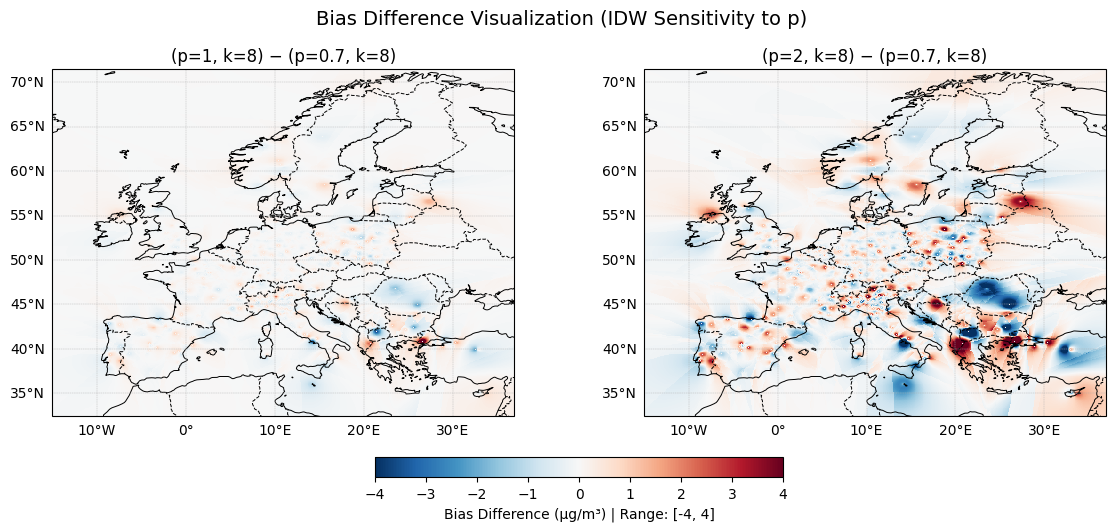

In [43]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# ======================================================
# FILES
# ======================================================
file_ref = "BaseCase_PM25_Y_IDW_ADD_0.7_8.nc"
file_1   = "BaseCase_PM25_Y_IDW_ADD_1_8.nc"
file_2   = "BaseCase_PM25_Y_IDW_ADD_2_8.nc"

# ======================================================
# LOAD DATA
# ======================================================
ds_ref = xr.open_dataset(file_ref)
ds_1   = xr.open_dataset(file_1)
ds_2   = xr.open_dataset(file_2)

bias_ref = ds_ref["Interpolated_Bias"].squeeze().values
bias_1   = ds_1["Interpolated_Bias"].squeeze().values
bias_2   = ds_2["Interpolated_Bias"].squeeze().values

lon = ds_ref["lon"].values
lat = ds_ref["lat"].values

# Convert to 2D grid (IMPORTANT)
lon2d, lat2d = np.meshgrid(lon, lat)

# ======================================================
# DIFFERENCES
# ======================================================
diff_1 = bias_1 - bias_ref   # (p=1) - (p=0.7)
diff_2 = bias_2 - bias_ref   # (p=2) - (p=0.7)

# ======================================================
#  MANUAL COLOR LIMITS (YOU CONTROL THESE)
# ======================================================
vmin = -4
vmax = 4

# ======================================================
# PLOT
# ======================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

titles = [
    "(p=1, k=8) − (p=0.7, k=8)",
    "(p=2, k=8) − (p=0.7, k=8)"
]

diffs = [diff_1, diff_2]

for i, ax in enumerate(axes):

    im = ax.pcolormesh(
        lon2d, lat2d, diffs[i],
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading='auto'
    )

    #  SHOW ONLY EMEP DOMAIN
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )

    # Map features
    ax.add_feature(cfeature.BORDERS, linestyle="--", linewidth=0.7)
    ax.coastlines(resolution="50m", linewidth=0.7)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.3)
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(titles[i])

# ======================================================
# COLORBAR
# ======================================================
plt.subplots_adjust(bottom=0.2)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.1
)

cbar.set_label(f"Bias Difference (µg/m³) | Range: [{vmin}, {vmax}]")

# ======================================================
# TITLE
# ======================================================
plt.suptitle("Bias Difference Visualization (IDW Sensitivity to p)", fontsize=14)

plt.show()